In [1]:
import yfinance as yf
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
import time
import finance_core

In [2]:
cpp_tools = finance_core.FinancialTools()

In [3]:
# Configuration
ticker = "AAPL"  # Stock to watch
window_size = 5   # SMA Window
loop_interval = 5 # Seconds between updates (Don't go too fast or Yahoo limits you)

In [4]:
print(f"Starting live feed for {ticker}...")

Starting live feed for AAPL...


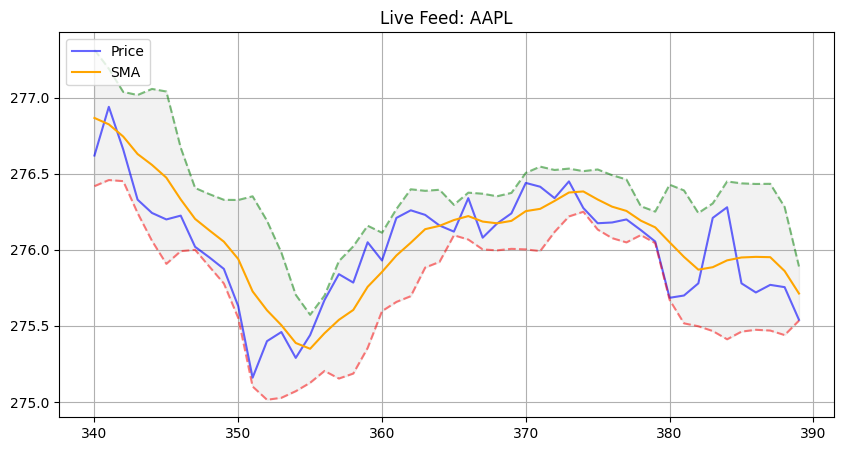

Stopped.


In [5]:
try:
    while True:
        # Fetch data
        data = yf.download(ticker, period="1d", interval="1m", progress=False)
        
        # Check if we have data
        if data.empty or len(data) < window_size:
            print("Waiting for more data...")
            time.sleep(loop_interval)
            continue
            
        # Get prices as list
        # We use .iloc to handle newer pandas versions safely
        prices = data['Close'].iloc[:, 0].tolist() if data['Close'].ndim > 1 else data['Close'].tolist()
        
        # Calculate SMA using C++
        sma, upper_band, lower_band = cpp_tools.calculate_bollinger(prices, window_size, 2.0)

        # --- 3. PLOTTING ---
        clear_output(wait=True)
        plt.figure(figsize=(10, 5))
        
        display_range = 50
        start_idx = max(0, len(prices) - display_range)
        
        # Plot Prices (Blue)
        plt.plot(range(start_idx, len(prices)), prices[start_idx:], 
                 label="Price", color='blue', alpha=0.6)
        
        # Align the bands (they are shorter than prices)
        if len(sma) > 0:
            offset = len(prices) - len(sma)
            visible_start = max(0, start_idx - offset)
            
            # X-axis for bands
            x_axis = range(offset + visible_start, len(prices))
            
            # Plot SMA (Orange)
            plt.plot(x_axis, sma[visible_start:], 
                     label="SMA", color='orange', linewidth=1.5)
            
            # Plot Bollinger Bands (Green/Red or filled area)
            plt.plot(x_axis, upper_band[visible_start:], color='green', linestyle='--', alpha=0.5)
            plt.plot(x_axis, lower_band[visible_start:], color='red', linestyle='--', alpha=0.5)
            
            # Cool visual: Fill the area between bands
            plt.fill_between(x_axis, 
                             lower_band[visible_start:], 
                             upper_band[visible_start:], 
                             color='gray', alpha=0.1)

        plt.title(f"Live Feed: {ticker}")
        plt.legend(loc='upper left')
        plt.grid(True)
        plt.show()

        time.sleep(loop_interval)
    
except KeyboardInterrupt:
    print("Stopped.")